In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt, detrend
from scipy.optimize import minimize, minimize_scalar
from pytdi.dsp import timeshift

In [2]:
data = np.load("measurement_data/DelayLineTest_20260127_134423.npy", mmap_mode="r")
print(data.shape, data.dtype)

(8583069,) [('Time (s)', '<f8'), ('Input 1 Set Frequency (Hz)', '<f8'), ('Input 1 Frequency (Hz)', '<f8'), ('Input 1 Phase (cyc)', '<f8'), ('Input 1 I (V)', '<f8'), ('Input 1 Q (V)', '<f8'), ('Input 2 Set Frequency (Hz)', '<f8'), ('Input 2 Frequency (Hz)', '<f8'), ('Input 2 Phase (cyc)', '<f8'), ('Input 2 I (V)', '<f8'), ('Input 2 Q (V)', '<f8'), ('Input 3 Set Frequency (Hz)', '<f8'), ('Input 3 Frequency (Hz)', '<f8'), ('Input 3 Phase (cyc)', '<f8'), ('Input 3 I (V)', '<f8'), ('Input 3 Q (V)', '<f8')]


In [45]:
settling_time = 15000

t = data['Time (s)']
m = data["Time (s)"] >= (data["Time (s)"][0] + settling_time)
t = t[m]

#### Delayed signal
f1     = data['Input 1 Frequency (Hz)'][m] # Hz
phi1   = data['Input 1 Phase (cyc)'][m] # cyc

#### DDS signal
f2     = data['Input 2 Frequency (Hz)'][m] # Hz
phi2   = data['Input 2 Phase (cyc)'][m] # cyc

#### No dealy signal
f3     = data['Input 3 Frequency (Hz)'][m] # Hz
phi3   = data['Input 3 Phase (cyc)'][m] # cyc

In [46]:
# Sanity check, from conf 150 Hz -ish
dt = np.mean(np.diff(t))
fs = 1 / dt
print("Sampling frequency (Hz):", fs)

Sampling frequency (Hz): 149.01161193847653


In [47]:
def detrend_lin(t, x):
    return x - np.polyval(np.polyfit(t, x, 1), t)

In [48]:
phi2_dt = phi2 - np.polyval(np.polyfit(t, phi2, 1), t)
jit_poly = phi2_dt / f2


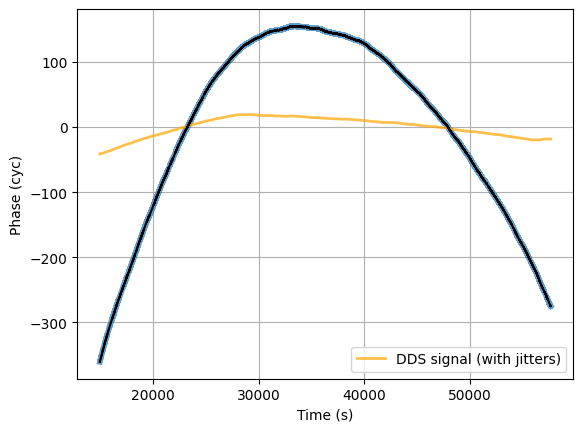

In [52]:

plt.plot(t, detrend_lin(t, phi1), linewidth=4, alpha=0.7)
plt.plot(t, detrend_lin(t, phi2), label="DDS signal (with jitters)", color="orange", linewidth=2, alpha=0.7)
plt.plot(t, detrend_lin(t, phi3), color="black")
plt.xlabel("Time (s)"); plt.ylabel("Phase (cyc)"); plt.grid(True); plt.legend()
plt.show()


C:\Users\kakruu\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


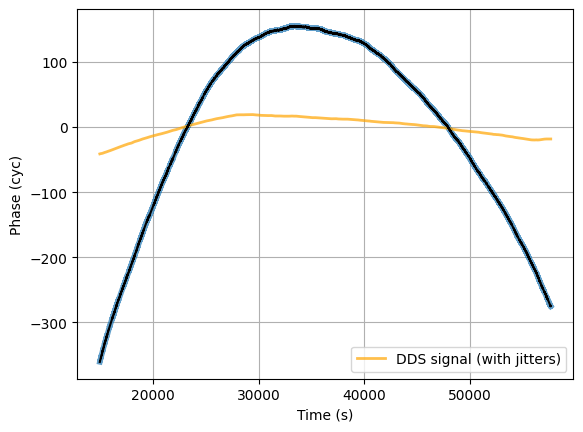

In [50]:

plt.plot(t, detrend(phi1), linewidth=4, alpha=0.7)
plt.plot(t, detrend(phi2), label="DDS signal (with jitters)", color="orange", linewidth=2, alpha=0.7)
plt.plot(t, detrend(phi3), color="black")
plt.xlabel("Time (s)"); plt.ylabel("Phase (cyc)"); plt.grid(True); plt.legend()
plt.show()



In [7]:
set_delay = 8.1 # s

In [8]:
def D(x, dt, tau, order=31): return timeshift(np.asarray(x, float), (tau/dt), order=order)
def asd(x, fs, nperseg=2**20):
    f, P = welch(x, fs, nperseg=nperseg, scaling="density")
    return f, np.sqrt(P)

In [9]:
sample = int(set_delay / dt)
print("shifting by ", sample*dt, "s")
m = 1
n = 1000

plot_stuff = False

phi1_detrended = detrend_lin(t, phi1)
if plot_stuff: plt.plot(t[m*sample:n*sample], phi1_detrended[m*sample:n*sample], linewidth=4, alpha=0.7, label="Delayed")

phi2_detrended = detrend_lin(t, phi2)
#if plot_stuff: plt.plot(t[:sample], phi2_detrended[:sample], label="DDS")

phi3_detrended = detrend_lin(t, phi3)
Dphi3 = D(phi3_detrended, dt, set_delay, order=31)
if plot_stuff:plt.plot(t[m*sample:n*sample], Dphi3[m*sample:n*sample], color="black",label="No delay")

if plot_stuff:plt.xlabel("Time (s)"); plt.ylabel("Phase (cyc)"); plt.grid(True); plt.legend()
if plot_stuff:plt.show()

shifting by  8.0933289984 s


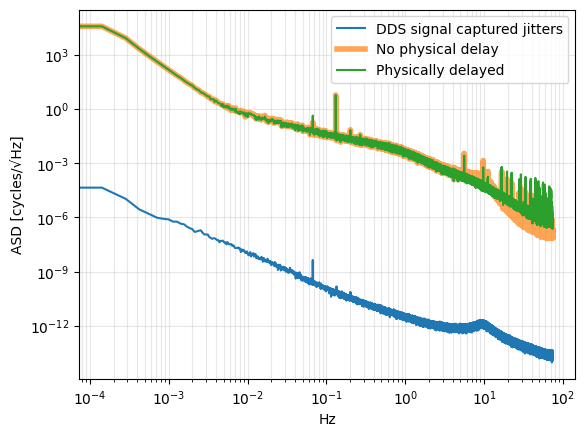

In [54]:

f, A = asd(phi1, fs)
f, A2 = asd(phi3, fs)
f, A3 = asd(jit_poly, fs)
plt.loglog(f, A3, label="DDS signal captured jitters"); plt.loglog(f, A2, linewidth=4,alpha=0.7, label="No physical delay"); plt.loglog(f, A, label="Physically delayed"); plt.xlabel("Hz"); plt.ylabel("ASD [cycles/√Hz]"); plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.show()

In [16]:

tau0, f0 = set_delay, 0.125
order, stride, win = 31, 10, 0.2


k = int(np.ceil(abs(tau0/dt))) + order + 2
t_new, phi1_ds, phi3_ds, f1_ds, jit_poly_ds = t[k:-k], phi1[k:-k], phi3[k:-k], f1[k:-k], jit_poly[k:-k]

# scalar cost: minimize residual power (mean-square)
def J(tau):
    r = phi1_ds - D(phi3_ds, dt, tau, order) + D(f1_ds * jit_poly_ds, dt, tau, order) - D(f1_ds, dt, tau, order) * jit_poly_ds
    r -= np.mean(r)
    return np.mean(r*r)


res = minimize_scalar(J, bounds=(tau0-win, tau0+win), method="bounded")
tau_hat = res.x
print("tau_hat =", tau_hat, "delta =", tau_hat - tau0)

tau_hat = 8.071422851813043 delta = -0.028577148186956336


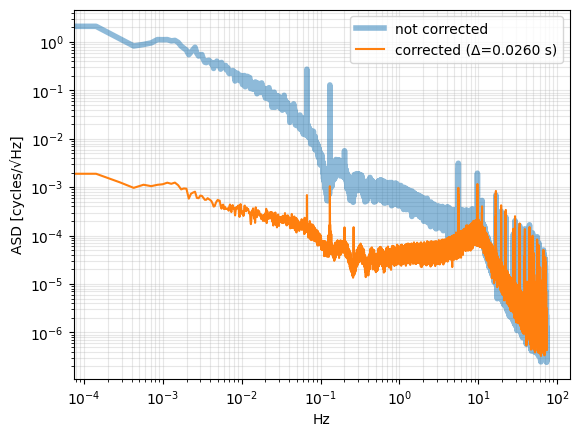

In [ ]:
# --- sweep tau offset and overlay ASDs on one plot ---
tau_offsets = np.arange(0.026, 0.027, 0.002)


order = 31

plt.figure()

# plot uncorrected once (independent of tau offset)
res2 = phi1 - D(phi3, dt, tau_hat , order)  # uses tau_hat just to keep D() signature consistent
k2 = int(np.ceil(abs(tau_hat/dt))) + order + 2
res2_cut = res2[k2:-k2]
f, A2 = asd(res2_cut, fs)
plt.loglog(f, A2, linewidth=4, alpha=0.5, label="not corrected")

for d in tau_offsets:
    tau = tau_hat + d

    Df1j  = D(f1 * jit_poly, dt, tau, order)
    Df1   = D(f1,            dt, tau, order)
    Dphi3 = D(phi3,          dt, tau, order)

    D_phi1_corrected = phi1 + Df1j - Df1 * jit_poly
    res = D_phi1_corrected - Dphi3

    # --- edge cut (filter support + shift) ---
    k = int(np.ceil(abs(tau/dt))) + order + 2
    res_cut = res[k:-k]

    # --- ASD ---
    f, A = asd(res_cut, fs)

    plt.loglog(f, A, label=f"corrected (Δ={tau_hat:.4f}+{d:.4f} s)")

plt.xlabel("Hz")
plt.ylabel("ASD [cycles/√Hz]")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


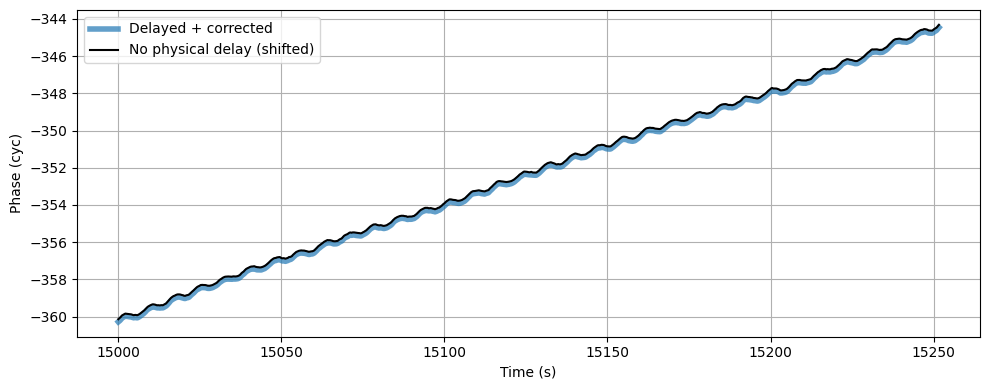

In [25]:
sample = 2500
m = 0
n = 15

# --- algebra (already have tau_hat) ---
tau = tau_hat +0.0299
order = 31

Df1j  = D(f1*jit_poly, dt, tau, order)
Df1   = D(f1,         dt, tau, order)
Dphi3 = D(phi3_detrended,       dt, tau, order)

D_phi1_corrected = phi1_detrended + Df1j - Df1*jit_poly
res = D_phi1_corrected - Dphi3

# --- same windowing as before ---
i0 = m * sample
i1 = n * sample

plt.figure(figsize=(10,4))

plt.plot(t[i0:i1], D_phi1_corrected[i0:i1],
         linewidth=4, alpha=0.7, label="Delayed + corrected")

plt.plot(t[i0:i1], Dphi3[i0:i1],
         color="black", label="No physical delay (shifted)")

#plt.plot(t, res, linestyle="--", label="Residual")

plt.xlabel("Time (s)")
plt.ylabel("Phase (cyc)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
